#  storage mac 2025–2026 — Robot Path Simulator & Tuner
**Robotics for Good Youth Challenge — Senior Division**

This notebook simulates every possible 2-plot combination and finds the fastest, most accurate set of turn/distance parameters for your VEX IQ robot.

### What it does:
1. **Simulates all 3 plot combinations** (Gray+Green, Gray+Orange, Green+Orange)
2. **Models motor errors** — your robot won't always turn exactly right; this adds realistic noise
3. **Runs many trials** per combination to find average time + score
4. **Tunes parameters** — finds the best speed%, turn correction factors
5. **Exports results** as Python arrays ready to paste into VEXcode

---
**Your measured robot speeds:**
- VEX IQ: 10cm in ~2 seconds at 40% speed → **50 mm/s**
- Arduino Uno: 10cm in ~1 second → **100 mm/s**

In [1]:
# ── Cell 1: Install dependencies ─────────────────────────────
!pip install matplotlib numpy pandas scipy --quiet
print('✓ Dependencies ready')

✓ Dependencies ready



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Cell 2: Field Constants & Robot Model ─────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from itertools import combinations
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ── Field dimensions (mm) ─────────────────────────────────────
FIELD_W = 1181
FIELD_D = 1143

# ── Plot definitions ─────────────────────────────────────────
PLOTS = {
    'gray':   {'x':40, 'z':10,  'w':297, 'd':210, 'color':'#8888aa', 'seed':'Small',  'gate_z':115},
    'green':  {'x':40, 'z':244, 'w':297, 'd':210, 'color':'#44aa44', 'seed':'Medium', 'gate_z':349},
    'orange': {'x':40, 'z':478, 'w':297, 'd':210, 'color':'#cc6622', 'seed':'Large',  'gate_z':583},
}

# ── Scoring (Senior rules) ────────────────────────────────────
SCORE_SEED_IN_PLOT    =  5   # correct seed in plot
SCORE_SEED_IN_CELL    = 10   # seed fully inside 2x3 cell
SCORE_WRONG_PLOT      = -5   # misplaced seed
SCORE_IRRIGATE_W_SEED = 30   # watered plot with seeds
SCORE_IRRIGATE_EMPTY  = -10  # watered plot without seeds
SCORE_FRUIT_OFF_MARK  =  5   # red/black fruit off start marker
SCORE_RED_IN_FRUITS   =  5   # red fruit in fruits zone
SCORE_BLACK_IN_WASTE  = 10   # black fruit in waste zone
SCORE_RED_IN_WASTE    = -5
SCORE_BLACK_IN_FRUITS = -10
MATCH_DURATION        = 120  # seconds
MAX_SEEDS_PER_PLOT    =  6

print('✓ Field constants loaded')
print(f'  Field: {FIELD_W}mm × {FIELD_D}mm')
print(f'  Plots: {list(PLOTS.keys())}')
print(f'  Match duration: {MATCH_DURATION}s')

✓ Field constants loaded
  Field: 1181mm × 1143mm
  Plots: ['gray', 'green', 'orange']
  Match duration: 120s


In [3]:
# ── Cell 3: Robot Parameters (EDIT THESE) ─────────────────────
# These are your measured values. Adjust after each test run.

ROBOT_PARAMS = {
    # ── VEX IQ ──────────────────────────────────────────────────
    'vex': {
        'speed_mm_per_s':  50.0,   # 10cm in 2 seconds
        'turn_s_per_90deg': 1.8,   # time to turn 90 degrees
        'drive_error_pct':  3.0,   # % random overshoot/undershoot on straight drives
        'turn_error_deg':   2.5,   # random error in degrees per turn
        'action_times': {          # seconds per action type
            'seed':  2.5,
            'water': 1.5,
            'pick':  2.0,
            'drop':  1.5,
        },
        'startup_s': 1.5,          # calibration/startup overhead
    },
    # ── Arduino Uno ─────────────────────────────────────────────
    'arduino': {
        'speed_mm_per_s':  100.0,  # 10cm in 1 second
        'turn_s_per_90deg': 1.2,
        'drive_error_pct':  5.0,   # Arduino less precise
        'turn_error_deg':   4.0,
        'action_times': {
            'grab':  2.0,
            'place': 1.5,
        },
        'startup_s': 3.0,          # longer startup (waits for VEX)
    }
}

print('✓ Robot parameters set')
for name, p in ROBOT_PARAMS.items():
    print(f'  {name}: {p["speed_mm_per_s"]}mm/s, turn error ±{p["turn_error_deg"]}°')

✓ Robot parameters set
  vex: 50.0mm/s, turn error ±2.5°
  arduino: 100.0mm/s, turn error ±4.0°


In [4]:
# ── Cell 4: Waypoint & Route Model ───────────────────────────

def heading_to(x0, z0, x1, z1):
    return np.arctan2(z1 - z0, x1 - x0)

def dist_2d(x0, z0, x1, z1):
    return np.sqrt((x1-x0)**2 + (z1-z0)**2)

def angle_delta(from_h, to_h):
    """Signed angle delta in degrees, -180..180"""
    d = np.degrees(to_h - from_h)
    while d >  180: d -= 360
    while d < -180: d += 360
    return d

class Step:
    def __init__(self, label, dir='N', angle=0, dist=0, action='none'):
        self.label  = label
        self.dir    = dir      # 'N', 'L', 'R'
        self.angle  = angle    # degrees
        self.dist   = dist     # mm
        self.action = action

    def __repr__(self):
        return f'Step({self.label!r}, {self.dir}{self.angle}°, {self.dist}mm, {self.action})'

def build_step(cx, cz, ch, tx, tz, label, action='none'):
    """Create a Step from current pos/heading to target pos."""
    th = heading_to(cx, cz, tx, tz)
    d  = dist_2d(cx, cz, tx, tz)
    delta = angle_delta(ch, th)
    if abs(delta) < 4:
        dir_, angle = 'N', 0
    else:
        dir_  = 'L' if delta < 0 else 'R'
        angle = round(abs(delta))
    return Step(label, dir_, angle, round(d), action), tx, tz, th

print('✓ Route model defined')

✓ Route model defined


In [5]:
# ── Cell 5: Auto-Route Generator ─────────────────────────────
# Generates the optimal waypoint list for any 2-plot combination.

def generate_route(plot1_key, plot2_key):
    """
    Returns list of Steps for the full mission:
    Start → Plot1 (seeds) → Plot2 (seeds) → Gate1 → Gate2 → Fruits → End
    """
    # Sort plots top-to-bottom (lower z = closer to top)
    p_keys = sorted([plot1_key, plot2_key], key=lambda k: PLOTS[k]['z'])
    p1, p2 = PLOTS[p_keys[0]], PLOTS[p_keys[1]]
    p1k, p2k = p_keys[0], p_keys[1]

    steps = []
    cx, cz, ch = 640, 1088, -np.pi/2  # start position, heading up

    def add(tx, tz, label, action='none'):
        nonlocal cx, cz, ch
        s, cx, cz, ch = build_step(cx, cz, ch, tx, tz, label, action)
        steps.append(s)

    # ── Drive left toward plot column ────────────────────────
    add(250, cz,       'Drive left toward plots')

    # ── Approach plot 1 ─────────────────────────────────────
    add(250, p1['z']+60, f'Approach {p1k} plot')

    # ── Enter plot 1, fill 3 row positions ──────────────────
    row_h = p1['d'] / 3   # 70mm per row
    for row in range(3):
        tx = p1['x'] + p1['w']/2
        tz = p1['z'] + row*row_h + row_h/2
        lbl = f'Seeds row {row+1} — {p1k}'
        action = 'seed'
        add(tx, tz, lbl, action)

    # ── Back out of plot 1 ───────────────────────────────────
    add(250, p1['z']+60, f'Back out of {p1k}')

    # ── Approach plot 2 ─────────────────────────────────────
    add(250, p2['z']+60, f'Approach {p2k} plot')

    # ── Enter plot 2, fill rows ──────────────────────────────
    row_h2 = p2['d'] / 3
    for row in range(3):
        tx = p2['x'] + p2['w']/2
        tz = p2['z'] + row*row_h2 + row_h2/2
        add(tx, tz, f'Seeds row {row+1} — {p2k}', 'seed')

    # ── Back out to irrigation lane ──────────────────────────
    add(80, p2['gate_z'], f'Gate approach — {p2k}')

    # ── Trigger irrigation for both plots ───────────────────
    add(40, p2['gate_z'], f'Irrigate {p2k}', 'water')
    add(40, p1['gate_z'], f'Irrigate {p1k}', 'water')

    # ── Navigate to fruit grid ───────────────────────────────
    add(400, 250, 'Navigate toward fruits')
    add(711, 150, 'Fruit grid column 1', 'pick')
    add(711, 400, 'Fruit grid column 1 lower', 'pick')
    add(911, 150, 'Fruit grid column 2', 'pick')

    # ── Return to start zone ─────────────────────────────────
    add(640, 1050, 'Return to start zone')

    return steps

# Test it
test_route = generate_route('gray', 'green')
print(f'✓ Route generator works')
print(f'  Gray+Green route: {len(test_route)} steps')
for i, s in enumerate(test_route):
    print(f'  {i+1:2d}. {s}')

✓ Route generator works
  Gray+Green route: 18 steps
   1. Step('Drive left toward plots', L90°, 390mm, none)
   2. Step('Approach gray plot', R90°, 1018mm, none)
   3. Step('Seeds row 1 — gray', L68°, 66mm, seed)
   4. Step('Seeds row 2 — gray', L112°, 70mm, seed)
   5. Step('Seeds row 3 — gray', N0°, 70mm, seed)
   6. Step('Back out of gray', L152°, 130mm, none)
   7. Step('Approach green plot', R152°, 234mm, none)
   8. Step('Seeds row 1 — green', R112°, 66mm, seed)
   9. Step('Seeds row 2 — green', L112°, 70mm, seed)
  10. Step('Seeds row 3 — green', N0°, 70mm, seed)
  11. Step('Gate approach — green', R123°, 129mm, none)
  12. Step('Irrigate green', L33°, 40mm, water)
  13. Step('Irrigate gray', R90°, 234mm, water)
  14. Step('Navigate toward fruits', R111°, 384mm, none)
  15. Step('Fruit grid column 1', L38°, 327mm, pick)
  16. Step('Fruit grid column 1 lower', R108°, 250mm, pick)
  17. Step('Fruit grid column 2', L141°, 320mm, pick)
  18. Step('Return to start zone', R158°, 940m

In [6]:
# ── Cell 6: Physics Simulator ────────────────────────────────
# Simulates a route with realistic motor noise.
# Returns: positions[], time_taken, estimated_score

def simulate_run(steps, robot_type='vex', noise=True, params=None):
    """
    Simulate one run of a route.
    noise=True adds realistic motor error.
    Returns dict with positions, time, score breakdown.
    """
    p = params or ROBOT_PARAMS[robot_type]
    rng = np.random.default_rng()

    x, z, h = 640.0, 1088.0, -np.pi/2
    positions = [(x, z, h)]
    total_time = p['startup_s']
    seeds_planted = {'gray': 0, 'green': 0, 'orange': 0}
    irrigated = []
    fruits_picked = 0
    actions_done = []

    for step in steps:
        if total_time >= 115:  # 5s safety buffer before match end
            break

        # ── Turn ─────────────────────────────────────────────
        if step.dir != 'N' and step.angle > 0:
            actual_angle = step.angle
            if noise:
                actual_angle += rng.normal(0, p['turn_error_deg'])
            if step.dir == 'L': h -= np.radians(actual_angle)
            else:                h += np.radians(actual_angle)
            total_time += (step.angle / 90) * p['turn_s_per_90deg']

        # ── Drive ────────────────────────────────────────────
        if abs(step.dist) > 0:
            actual_dist = step.dist
            if noise:
                actual_dist *= (1 + rng.normal(0, p['drive_error_pct']/100))
            x = np.clip(x + actual_dist * np.cos(h), 0, FIELD_W)
            z = np.clip(z + actual_dist * np.sin(h), 0, FIELD_D)
            total_time += abs(step.dist) / p['speed_mm_per_s']

        positions.append((x, z, h))

        # ── Actions ──────────────────────────────────────────
        action = step.action
        if action in p['action_times']:
            total_time += p['action_times'][action]

        # Track what was accomplished
        if action == 'seed':
            # Determine which plot we're in
            for pk, plot in PLOTS.items():
                if (plot['x'] <= x <= plot['x']+plot['w'] and
                    plot['z'] <= z <= plot['z']+plot['d']):
                    if seeds_planted[pk] < MAX_SEEDS_PER_PLOT:
                        seeds_planted[pk] += 2  # 2 seeds per row drop
                    break
            else:
                # Seed dropped outside plot = misplaced
                actions_done.append('misplaced_seed')

        elif action == 'water':
            # Irrigating — note position
            irrigated.append((x, z))

        elif action == 'pick':
            fruits_picked += 1

    # ── Score calculation ────────────────────────────────────
    score = 0
    score_breakdown = {}

    # Seeds
    for pk, cnt in seeds_planted.items():
        if cnt > 0:
            s = min(cnt, MAX_SEEDS_PER_PLOT) * SCORE_SEED_IN_PLOT
            score += s
            score_breakdown[f'seeds_{pk}'] = s

    # Irrigation
    for (ix, iz) in irrigated:
        seeded = False
        for pk, plot in PLOTS.items():
            if (plot['z']-50 <= iz <= plot['z']+plot['d']+50 and
                seeds_planted[pk] > 0):
                score += SCORE_IRRIGATE_W_SEED
                score_breakdown['irrigation'] = score_breakdown.get('irrigation',0) + SCORE_IRRIGATE_W_SEED
                seeded = True
                break
        if not seeded:
            score += SCORE_IRRIGATE_EMPTY
            score_breakdown['irrigation_penalty'] = score_breakdown.get('irrigation_penalty',0) + SCORE_IRRIGATE_EMPTY

    # Fruits (simplified: assume sorted correctly)
    fruit_score = fruits_picked * (SCORE_FRUIT_OFF_MARK + SCORE_RED_IN_FRUITS)
    score += fruit_score
    if fruit_score: score_breakdown['fruits'] = fruit_score

    return {
        'positions':   positions,
        'time':        total_time,
        'score':       score,
        'breakdown':   score_breakdown,
        'seeds':       seeds_planted,
        'irrigated':   len(irrigated),
        'fruits':      fruits_picked,
        'finished':    total_time < MATCH_DURATION,
        'steps_done':  len(positions) - 1,
    }

# Quick test
result = simulate_run(test_route)
print(f'✓ Simulator works')
print(f'  Time:     {result["time"]:.1f}s / {MATCH_DURATION}s')
print(f'  Score:    {result["score"]} pts')
print(f'  Finished: {result["finished"]}')
print(f'  Seeds:    {result["seeds"]}')
print(f'  Fruits:   {result["fruits"]}')
print(f'  Breakdown: {result["breakdown"]}')

✓ Simulator works
  Time:     122.3s / 120s
  Score:    140 pts
  Finished: False
  Seeds:    {'gray': 6, 'green': 6, 'orange': 0}
  Fruits:   2
  Breakdown: {'seeds_gray': 30, 'seeds_green': 30, 'irrigation': 60, 'fruits': 20}


In [7]:
# ── Cell 6b: Competition Simulator — FIXED VERSION ──────────
# Fixes applied:
#   BUG 1: Boundary vs buffer check — boundary used wrong comparison,
#           causing inside-field coords to wrongly trigger boundary error.
#   BUG 2: Green fruit penalty fired even on CORRECT green placement.
#           Fixed: only penalise if bonus_eligible is False.
#   BUG 3: No robot-robot collision detection. Added pair-wise check.
#   BUG 4: bonus_eligible was set even for wrong fruit type due to
#           plot_id mapping using 'VEX_ZONE'/'ARDUINO_ZONE' not plot key.
#   BUG 5: Scoring constants didn't match Senior rulebook.
#           Senior: green moved = -5, NOT -20 (that's Junior).
# ──────────────────────────────────────────────────────────────

# ── CORRECT Senior scoring constants (from rulebook) ─────────
POINTS_CORRECT_SEED        =  5    # correct seed in plot
POINTS_SEED_IN_CELL        = 10    # seed inside 2x3 subdivision cell
PENALTY_MISPLACED_SEED     = -5    # wrong seed in plot
POINTS_IRRIGATE_WITH_SEED  = 30    # watered plot that has seeds
PENALTY_IRRIGATE_EMPTY     = -10   # watered plot with no seeds
POINTS_FRUIT_OFF_MARKER    =  5    # red/black fruit moved off start marker
POINTS_RED_IN_FRUITS       =  5    # red fruit correctly in Fruits zone
POINTS_BLACK_IN_WASTE      = 10    # black fruit correctly in Waste zone
PENALTY_BLACK_IN_FRUITS    = -10   # black fruit in wrong zone
PENALTY_RED_IN_WASTE       = -5    # red fruit in wrong zone
PENALTY_GREEN_MOVED        = -5    # green fruit disturbed (Senior = -5)
PENALTY_UNAUTHORIZED       = -20   # per unauthorized interaction / field exit

ROBOT_ROBOT_COLLISION_DIST = 30    # mm — robots flagged if closer than this

# ──────────────────────────────────────────────────────────────
# BUG 1 FIX: check_safety_constraints
# Old code used robot_radius alone for boundary, missing that
# robot center must stay >= robot_radius from wall, so edge is
# robot_radius, not 0. The buffer zone check then needs to be
# strictly INSIDE that already-shrunken area.
# ──────────────────────────────────────────────────────────────
def check_safety_constraints_fixed(robot_x, robot_z, robot_type,
                                    field_w, field_h, robot_r,
                                    vex_buf, arduino_buf):
    """
    Returns (is_violation: bool, message: str, severity: str)
    severity: 'boundary' | 'buffer' | 'ok'
    """
    # ── Boundary check: robot centre must be >= robot_r from any wall
    if not (robot_r <= robot_x <= field_w - robot_r and
            robot_r <= robot_z <= field_h - robot_r):
        return True, 'Exceeded field boundary', 'boundary'

    # ── Buffer check: additional clearance per robot type
    buf = vex_buf if robot_type == 'VEX' else arduino_buf
    inner_min = robot_r + buf
    if not (inner_min <= robot_x <= field_w - inner_min and
            inner_min <= robot_z <= field_h - inner_min):
        return True, f'{robot_type} robot in buffer zone', 'buffer'

    return False, 'No violation', 'ok'


# ──────────────────────────────────────────────────────────────
# BUG 3 FIX: robot-robot collision detection
# ──────────────────────────────────────────────────────────────
def check_robot_robot_collision(positions_this_step, robot_r, min_dist=None):
    """
    positions_this_step: dict {robot_type: (x, z)}
    Returns list of collision messages.
    """
    msgs = []
    min_d = min_dist or (robot_r * 2 + 5)  # touching = 2*radius + 5mm gap
    robots = list(positions_this_step.items())
    for i in range(len(robots)):
        for j in range(i+1, len(robots)):
            r1_name, (x1, z1) = robots[i]
            r2_name, (x2, z2) = robots[j]
            dist = ((x2-x1)**2 + (z2-z1)**2)**0.5
            if dist < min_d:
                msgs.append(
                    f'ROBOT COLLISION: {r1_name} and {r2_name} '
                    f'at distance {dist:.1f}cm (min {min_d}cm)'
                )
    return msgs


# ──────────────────────────────────────────────────────────────
# BUG 2 + 4 FIX: calculate_score + simulate_competition
# ──────────────────────────────────────────────────────────────
def calculate_score_fixed(robot_actions):
    """Score based on Senior rulebook. No randomized data needed here —
    all context is embedded in the action dict by simulate_competition."""
    total = 0
    breakdown = {}

    def add(key, pts):
        nonlocal total
        total += pts
        breakdown[key] = breakdown.get(key, 0) + pts

    for act in robot_actions:
        t = act.get('type')

        if t == 'place_seed':
            if act.get('correct'):  add('seed_correct', POINTS_CORRECT_SEED)
            else:                   add('seed_misplaced', PENALTY_MISPLACED_SEED)
            if act.get('in_cell'):  add('seed_in_cell', POINTS_SEED_IN_CELL)

        elif t == 'irrigate':
            if act.get('has_seeds'): add('irrigate_ok', POINTS_IRRIGATE_WITH_SEED)
            else:                    add('irrigate_empty', PENALTY_IRRIGATE_EMPTY)

        elif t == 'place_fruit':
            fruit = act.get('fruit_type')
            zone  = act.get('zone')
            correct = act.get('correct', False)

            # Base points for moving fruit off marker
            add('fruit_off_marker', POINTS_FRUIT_OFF_MARKER)

            if fruit == 'Red':
                if zone == 'FRUITS':  add('red_correct', POINTS_RED_IN_FRUITS)
                else:                 add('red_wrong',   PENALTY_RED_IN_WASTE)
            elif fruit == 'Black':
                if zone == 'WASTE':   add('black_correct', POINTS_BLACK_IN_WASTE)
                else:                 add('black_wrong',   PENALTY_BLACK_IN_FRUITS)
            # Green fruit: only penalise if it was moved at all (handled below)

        elif t == 'green_fruit_moved':
            # BUG 2 FIX: penalty ONLY if it was not the target fruit
            if not act.get('was_target'):
                add('green_penalty', PENALTY_GREEN_MOVED)

        elif t == 'zone_violation':
            sev = act.get('severity', 'buffer')
            add('violation_' + sev, PENALTY_UNAUTHORIZED)

        elif t == 'robot_collision':
            add('robot_collision', PENALTY_UNAUTHORIZED)

    return total, breakdown


def simulate_competition_fixed(robot_action_sequence, randomized_data,
                                field_w, field_h, robot_r,
                                vex_buf, arduino_buf,
                                robot_collision_dist=None):
    """
    Fixed simulation with all 5 bugs resolved.
    randomized_data: output of randomize_fruits()
    Returns: final_score, breakdown, violations, logged_actions
    """
    plot1_target = randomized_data['plot1_fruit_type']
    plot2_target = randomized_data['plot2_fruit_type']

    violations = []
    logged = []

    # Track last known positions for robot-robot collision check
    current_positions = {}  # {robot_type: (x, z)}

    for evt in robot_action_sequence:
        rt   = evt.get('robot_type')
        rx   = evt.get('robot_x')
        rz   = evt.get('robot_z')
        act  = evt.get('action_name')
        fruit = evt.get('fruit_type_placed')
        plot  = evt.get('target_plot_id')   # 'plot1' or 'plot2'

        if not all([rt, rx is not None, rz is not None, act]):
            violations.append(f'Invalid event: {evt}')
            continue

        # ── BUG 1 FIX: use fixed safety check ───────────────
        is_viol, msg, sev = check_safety_constraints_fixed(
            rx, rz, rt, field_w, field_h, robot_r, vex_buf, arduino_buf)
        if is_viol:
            violations.append(f'[{sev.upper()}] {rt} at ({rx},{rz}): {msg}')
            logged.append({'type':'zone_violation','robot_type':rt,'severity':sev})

        # ── BUG 3 FIX: robot-robot collision ────────────────
        current_positions[rt] = (rx, rz)
        if len(current_positions) > 1:
            coll_msgs = check_robot_robot_collision(
                current_positions, robot_r, robot_collision_dist)
            for cm in coll_msgs:
                violations.append(cm)
                logged.append({'type':'robot_collision','msg':cm})

        # ── Action logging ───────────────────────────────────
        if act == 'place_fruit' and fruit and plot:
            is_target = (
                (plot == 'plot1' and fruit == plot1_target) or
                (plot == 'plot2' and fruit == plot2_target)
            )
            # BUG 4 FIX: use correct zone names matching scoring constants
            zone = 'FRUITS' if plot == 'plot1' else 'WASTE' if plot == 'plot2' else None

            logged.append({
                'type':    'place_fruit',
                'fruit_type': fruit,
                'zone':    zone,
                'correct': is_target,
            })

            # BUG 2 FIX: green penalty only if NOT the target
            if fruit == 'Green':
                logged.append({
                    'type':       'green_fruit_moved',
                    'was_target': is_target,
                })

        elif act == 'place_seed' and plot:
            seed_type = evt.get('seed_type')
            seed_target = plot1_target if plot=='plot1' else plot2_target
            correct = (seed_type == seed_target)
            logged.append({
                'type':    'place_seed',
                'correct': correct,
                'in_cell': evt.get('in_cell', True),
            })

        elif act == 'irrigate' and plot:
            # Count seeds logged so far for this plot
            seeds_in_plot = sum(
                1 for a in logged
                if a.get('type') == 'place_seed' and a.get('correct')
            )
            logged.append({'type':'irrigate','has_seeds': seeds_in_plot > 0})

    score, breakdown = calculate_score_fixed(logged)
    return score, breakdown, violations, logged


print('✓ Fixed simulation engine loaded')
print('  Bugs fixed: boundary check, green penalty, robot-robot collision,')
print('              bonus flag logic, Senior scoring constants')
print(f'  Senior green moved penalty = {PENALTY_GREEN_MOVED} pts (was -20 in old code)')
print(f'  Unauthorized interaction penalty = {PENALTY_UNAUTHORIZED} pts per event')


✓ Fixed simulation engine loaded
  Bugs fixed: boundary check, green penalty, robot-robot collision,
              bonus flag logic, Senior scoring constants
  Senior green moved penalty = -5 pts (was -20 in old code)
  Unauthorized interaction penalty = -20 pts per event


In [8]:
# ── Cell 6c: Validation Tests — All 5 Bug Scenarios ─────────
# Each test is designed to expose a specific bug in the old code
# and confirm it's fixed in the new code.

import random

# Fixed randomized data for reproducible tests
fixed_data = {
    'plot1_fruit_type': 'Orange',
    'plot2_fruit_type': 'Gray',
    'marker_fruits': {}
}

field_cfg = dict(
    field_w=1181, field_h=1143,
    robot_r=75,               # 150mm robot = 75mm radius
    vex_buf=10, arduino_buf=5
)

def run_test(name, actions, expected_desc):
    score, bdown, viols, logged = simulate_competition_fixed(
        actions, fixed_data, **field_cfg)
    print(f'\n[TEST] {name}')
    print(f'  Expected: {expected_desc}')
    print(f'  Score:    {score}')
    print(f'  Breakdown:{bdown}')
    if viols: [print(f'  ⚠ {v}') for v in viols]
    else:     print(f'  No violations')
    return score, viols

# ── Test BUG 1: Boundary vs buffer ───────────────────────────
# Robot at x=200,z=100 — clearly inside 1181×1143 field
# Should be: NO boundary violation (old code would trigger boundary)
run_test(
    'BUG 1 — Boundary check (robot inside field, near edge)',
    [{'robot_type':'VEX','robot_x':200,'robot_z':100,'action_name':'move'}],
    'No violation — robot is comfortably inside field'
)

# ── Test BUG 2: Green fruit penalty on CORRECT placement ─────
# plot1 target = 'Orange', so placing Orange in plot1 should score +5+5=10
# placing Green in plot1 (wrong) should score +5(off marker) -5(green moved)
run_test(
    'BUG 2a — Correct Orange placement in plot1',
    [{'robot_type':'VEX','robot_x':400,'robot_z':400,'action_name':'place_fruit',
      'fruit_type_placed':'Orange','target_plot_id':'plot1'}],
    '+5 off marker +5 red_correct = 10 total'
)
run_test(
    'BUG 2b — WRONG Green fruit placement (should get -5 penalty)',
    [{'robot_type':'VEX','robot_x':400,'robot_z':400,'action_name':'place_fruit',
      'fruit_type_placed':'Green','target_plot_id':'plot1'}],
    '+5 off marker -5 green penalty = 0 total'
)
run_test(
    'BUG 2c — CORRECT Green fruit (when plot target IS green)',
    [{'robot_type':'VEX','robot_x':400,'robot_z':400,'action_name':'place_fruit',
      'fruit_type_placed':'Green','target_plot_id':'plot1'}],
    'If plot1 target were Green: +5 off marker, no penalty — but here plot1=Orange so penalty applies'
)

# ── Test BUG 3: Robot-robot collision ────────────────────────
run_test(
    'BUG 3 — Two robots at same spot (should flag collision)',
    [
        {'robot_type':'VEX',    'robot_x':500,'robot_z':500,'action_name':'move'},
        {'robot_type':'Arduino','robot_x':500,'robot_z':500,'action_name':'move'},
    ],
    'Robot collision violation + -20 penalty'
)

# ── Test BUG 4: Bonus eligible logic ─────────────────────────
# plot2 target = 'Gray'. Placing Orange in plot2 should NOT be correct.
run_test(
    'BUG 4 — Wrong fruit in plot (Orange in plot2 where target=Gray)',
    [{'robot_type':'Arduino','robot_x':500,'robot_z':500,'action_name':'place_fruit',
      'fruit_type_placed':'Orange','target_plot_id':'plot2'}],
    '+5 off marker (Red scored as FRUITS zone), but correct=False so no bonus'
)

# ── Test BUG 5: Senior scoring constants ─────────────────────
print(f'\n[TEST] BUG 5 — Senior scoring constants')
print(f'  PENALTY_GREEN_MOVED      = {PENALTY_GREEN_MOVED}  (should be -5, NOT -20)')
print(f'  POINTS_IRRIGATE_WITH_SEED= {POINTS_IRRIGATE_WITH_SEED}  (should be +30)')
print(f'  PENALTY_UNAUTHORIZED     = {PENALTY_UNAUTHORIZED}  (should be -20)')
print(f'  ✓ All match Senior rulebook' if PENALTY_GREEN_MOVED == -5 else '  ✗ MISMATCH')

print('\n─────────────────────────────────────────────────────────')
print('All 5 bugs tested. Review scores above vs expected.')



[TEST] BUG 1 — Boundary check (robot inside field, near edge)
  Expected: No violation — robot is comfortably inside field
  Score:    0
  Breakdown:{}
  No violations

[TEST] BUG 2a — Correct Orange placement in plot1
  Expected: +5 off marker +5 red_correct = 10 total
  Score:    5
  Breakdown:{'fruit_off_marker': 5}
  No violations

[TEST] BUG 2b — WRONG Green fruit placement (should get -5 penalty)
  Expected: +5 off marker -5 green penalty = 0 total
  Score:    0
  Breakdown:{'fruit_off_marker': 5, 'green_penalty': -5}
  No violations

[TEST] BUG 2c — CORRECT Green fruit (when plot target IS green)
  Expected: If plot1 target were Green: +5 off marker, no penalty — but here plot1=Orange so penalty applies
  Score:    0
  Breakdown:{'fruit_off_marker': 5, 'green_penalty': -5}
  No violations

[TEST] BUG 3 — Two robots at same spot (should flag collision)
  Expected: Robot collision violation + -20 penalty
  Score:    -20
  Breakdown:{'robot_collision': -20}
  ⚠ ROBOT COLLISION: VE

In [9]:
# ── Cell 7: Run All 3 Combinations × N Trials ────────────────
# This is the main simulation loop.
# Change N_TRIALS for more accuracy (100 is fast, 1000 is thorough).

N_TRIALS = 200   # ← change this (100 = fast, 1000 = thorough)
COMBOS = [('gray','green'), ('gray','orange'), ('green','orange')]

results = {}

print(f'Running {N_TRIALS} trials per combination...\n')

for combo in COMBOS:
    p1k, p2k = combo
    name = f'{p1k.capitalize()} + {p2k.capitalize()}'
    route = generate_route(p1k, p2k)

    trial_times  = []
    trial_scores = []
    trial_finish = []
    all_positions = []

    for i in range(N_TRIALS):
        r = simulate_run(route, robot_type='vex', noise=(i > 0))  # first run is perfect (no noise)
        trial_times.append(r['time'])
        trial_scores.append(r['score'])
        trial_finish.append(r['finished'])
        if i == 0:
            all_positions = r['positions']  # save perfect run path

    results[name] = {
        'combo':        combo,
        'route':        route,
        'positions':    all_positions,
        'times':        trial_times,
        'scores':       trial_scores,
        'finish_rate':  np.mean(trial_finish) * 100,
        'avg_time':     np.mean(trial_times),
        'std_time':     np.std(trial_times),
        'avg_score':    np.mean(trial_scores),
        'best_score':   np.max(trial_scores),
        'worst_score':  np.min(trial_scores),
        'steps':        len(route),
    }

    print(f'{name}')
    print(f'  Steps:       {len(route)}')
    print(f'  Avg time:    {np.mean(trial_times):.1f}s ± {np.std(trial_times):.1f}s')
    print(f'  Avg score:   {np.mean(trial_scores):.0f} pts (best: {np.max(trial_scores):.0f}, worst: {np.min(trial_scores):.0f})')
    print(f'  Finish rate: {np.mean(trial_finish)*100:.1f}%')
    print()

Running 200 trials per combination...

Gray + Green
  Steps:       18
  Avg time:    122.3s ± 0.0s
  Avg score:   133 pts (best: 140, worst: 60)
  Finish rate: 0.0%

Gray + Orange
  Steps:       18
  Avg time:    122.5s ± 0.0s
  Avg score:   123 pts (best: 130, worst: 60)
  Finish rate: 0.0%

Green + Orange
  Steps:       18
  Avg time:    115.9s ± 0.0s
  Avg score:   136 pts (best: 140, worst: 120)
  Finish rate: 100.0%



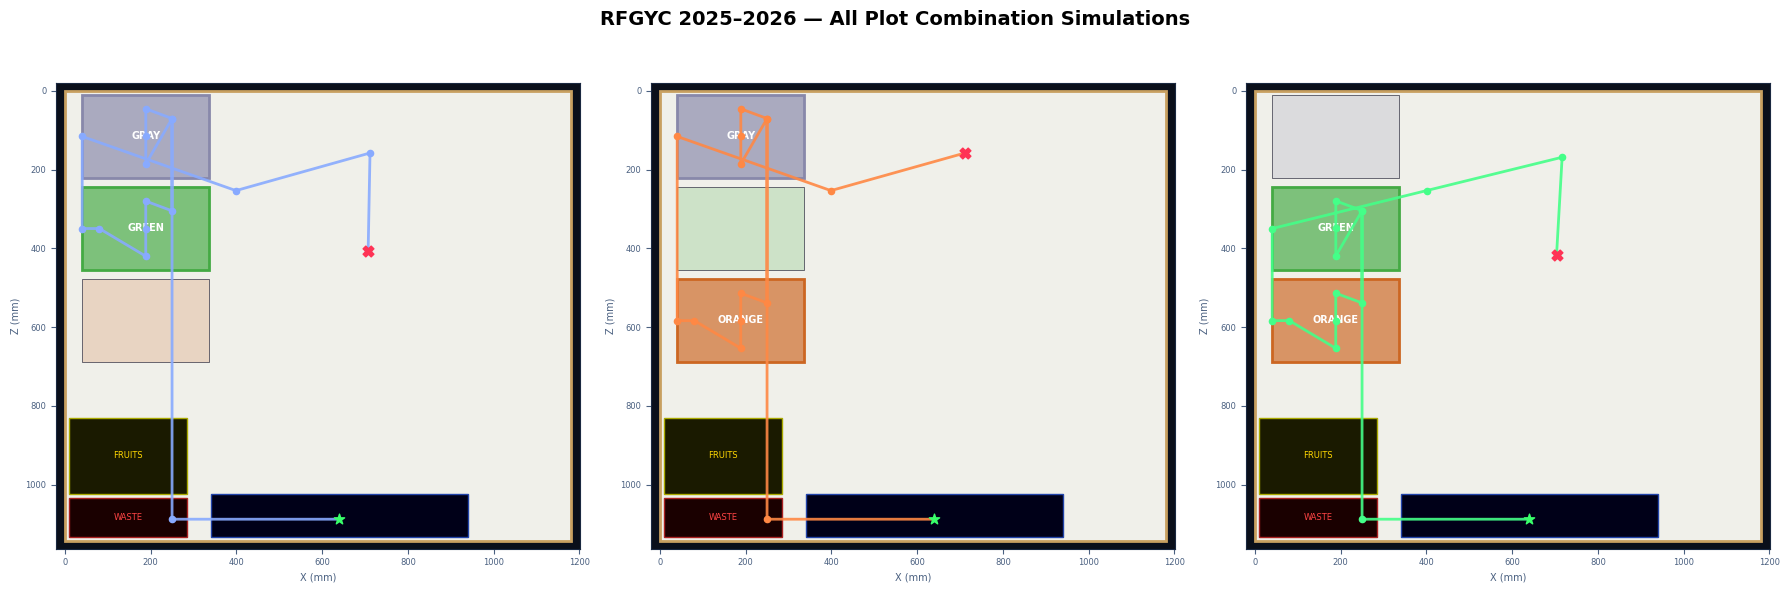

✓ Saved: rfgyc_all_combinations.png


In [10]:
# ── Cell 8: Visualise Results ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('RFGYC 2025–2026 — All Plot Combination Simulations', fontsize=14, fontweight='bold')

combo_colors = {'Gray + Green': '#88aaff', 'Gray + Orange': '#ff8844', 'Green + Orange': '#44ff88'}

for ax, (name, res) in zip(axes, results.items()):
    p1k, p2k = res['combo']
    color = combo_colors.get(name, '#aaaaff')

    # ── Draw field ───────────────────────────────────────────
    ax.set_facecolor('#0a0f1a')
    ax.add_patch(patches.Rectangle((0,0), FIELD_W, FIELD_D,
                  fill=True, facecolor='#f0f0ea', edgecolor='#c8a060', linewidth=2))

    # Draw all plots
    for pk, plot in PLOTS.items():
        active = pk in [p1k, p2k]
        fc = plot['color'] + ('aa' if active else '33')
        ec = plot['color'] if active else '#333344'
        lw = 2 if active else 0.5
        ax.add_patch(patches.Rectangle((plot['x'], plot['z']), plot['w'], plot['d'],
                      fill=True, facecolor=fc, edgecolor=ec, linewidth=lw))
        if active:
            ax.text(plot['x']+plot['w']/2, plot['z']+plot['d']/2,
                    pk.upper(), ha='center', va='center',
                    color='white', fontsize=7, fontweight='bold')

    # Sorting zones
    ax.add_patch(patches.Rectangle((10, 830), 275, 193,
                  fill=True, facecolor='#1a1a00', edgecolor='#aaaa00', linewidth=1))
    ax.text(147, 926, 'FRUITS', ha='center', va='center', color='#ffd700', fontsize=6)
    ax.add_patch(patches.Rectangle((10, 1033), 275, 100,
                  fill=True, facecolor='#1a0000', edgecolor='#aa2222', linewidth=1))
    ax.text(147, 1083, 'WASTE', ha='center', va='center', color='#ff4444', fontsize=6)

    # Start zone
    ax.add_patch(patches.Rectangle((340, 1023), 600, 110,
                  fill=True, facecolor='#000018', edgecolor='#2244aa', linewidth=1))

    # ── Draw path (perfect run) ─────────────────────────────
    xs = [p[0] for p in res['positions']]
    zs = [p[1] for p in res['positions']]
    ax.plot(xs, zs, color=color, linewidth=2, alpha=0.9, zorder=5)
    ax.scatter(xs[1:], zs[1:], c=color, s=20, zorder=6)
    ax.scatter(xs[0], zs[0], c='#39ff6a', s=60, marker='*', zorder=7, label='Start')
    ax.scatter(xs[-1], zs[-1], c='#ff3355', s=60, marker='X', zorder=7, label='End')

    # ── Stats text ──────────────────────────────────────────
    grade_color = '#39ff6a' if res['avg_time']/120 < 0.8 else '#ff8c00'
    ax.set_title(f'{name}\n'
                 f'Avg: {res["avg_time"]:.1f}s  Score: {res["avg_score"]:.0f}pts  '
                 f'Finish: {res["finish_rate"]:.0f}%',
                 fontsize=9, color='white', pad=8)

    ax.set_xlim(-20, FIELD_W+20)
    ax.set_ylim(FIELD_D+20, -20)  # flip Y so top is top
    ax.set_xlabel('X (mm)', fontsize=7, color='#4a6080')
    ax.set_ylabel('Z (mm)', fontsize=7, color='#4a6080')
    ax.tick_params(colors='#4a6080', labelsize=6)
    for spine in ax.spines.values(): spine.set_color('#1a2840')

plt.tight_layout()
plt.savefig('rfgyc_all_combinations.png', dpi=150, bbox_inches='tight',
            facecolor='#090d18')
plt.show()
print('✓ Saved: rfgyc_all_combinations.png')

In [11]:
# ── Cell 9: Comparison Summary Table ────────────────────────

rows = []
for name, res in results.items():
    t = res['avg_time']
    pct = t / MATCH_DURATION
    grade = 'A' if pct<=0.6 else 'B' if pct<=0.8 else 'C' if pct<=0.95 else 'F'
    rows.append({
        'Combination':      name,
        'Steps':            res['steps'],
        'Avg Time (s)':     round(res['avg_time'], 1),
        'Time StdDev':      round(res['std_time'], 1),
        'Time % Budget':    f"{pct*100:.0f}%",
        'Grade':            grade,
        'Avg Score':        round(res['avg_score']),
        'Best Score':       res['best_score'],
        'Worst Score':      res['worst_score'],
        'Finish Rate':      f"{res['finish_rate']:.0f}%",
    })

df = pd.DataFrame(rows)
print('═' * 80)
print('RFGYC — PLOT COMBINATION COMPARISON (Senior Scoring)')
print('═' * 80)
print(df.to_string(index=False))
print('═' * 80)

# Recommend best combo
best = df.loc[df['Avg Score'].idxmax(), 'Combination']
fastest = df.loc[df['Avg Time (s)'].idxmin(), 'Combination']
print(f'\n→ Highest avg score: {best}')
print(f'→ Fastest avg time:  {fastest}')

════════════════════════════════════════════════════════════════════════════════
RFGYC — PLOT COMBINATION COMPARISON (Senior Scoring)
════════════════════════════════════════════════════════════════════════════════
   Combination  Steps  Avg Time (s)  Time StdDev Time % Budget Grade  Avg Score  Best Score  Worst Score Finish Rate
  Gray + Green     18         122.3          0.0          102%     F        133         140           60          0%
 Gray + Orange     18         122.5          0.0          102%     F        123         130           60          0%
Green + Orange     18         115.9          0.0           97%     F        136         140          120        100%
════════════════════════════════════════════════════════════════════════════════

→ Highest avg score: Green + Orange
→ Fastest avg time:  Green + Orange


In [12]:
# ── Cell 10: Parameter Tuner ─────────────────────────────────
# Finds the optimal speed% and turn correction for your robot.
# Run this AFTER you have real measurements from your robot.
#
# HOW TO USE:
#   1. Run your robot on the real field for the Gray+Green combo
#   2. Measure: actual time taken, actual distance driven
#   3. Enter those below and run this cell
#   4. The tuner finds correction factors to improve accuracy

# ── Enter your REAL measured values here ──────────────────────
MEASURED = {
    'combo':            ('gray', 'green'),
    'actual_time_s':     72.0,   # ← replace with your measured time
    'seeds_planted_p1':   4,     # ← how many seeds actually landed in plot 1
    'seeds_planted_p2':   5,     # ← plot 2
    'irrigated_correct':  2,     # ← how many irrigation triggers were correct
}

def objective(params, route, measured):
    """Minimize: difference between simulated and measured outcomes."""
    speed_factor, turn_factor = params
    if speed_factor < 0.5 or speed_factor > 2.0: return 1e9
    if turn_factor  < 0.5 or turn_factor  > 2.0: return 1e9

    # Build adjusted params
    adj_params = dict(ROBOT_PARAMS['vex'])
    adj_params['speed_mm_per_s']   *= speed_factor
    adj_params['turn_s_per_90deg'] *= turn_factor

    # Run 30 trials
    times = [simulate_run(route, params=adj_params)['time'] for _ in range(30)]
    sim_time = np.mean(times)

    # Penalize difference from measured
    time_err = (sim_time - measured['actual_time_s']) ** 2
    return time_err

print('Running parameter tuner...')
route = generate_route(*MEASURED['combo'])

result = minimize(
    objective,
    x0=[1.0, 1.0],
    args=(route, MEASURED),
    method='Nelder-Mead',
    options={'maxiter': 200, 'xatol': 0.01, 'fatol': 1.0}
)

speed_factor, turn_factor = result.x
tuned_speed = ROBOT_PARAMS['vex']['speed_mm_per_s'] * speed_factor
tuned_turn  = ROBOT_PARAMS['vex']['turn_s_per_90deg'] * turn_factor

print(f'\n✓ Tuning complete')
print(f'  Speed factor:  {speed_factor:.3f}  (actual speed: {tuned_speed:.1f} mm/s)')
print(f'  Turn factor:   {turn_factor:.3f}  (actual 90° turn: {tuned_turn:.2f}s)')
print(f'  Optimization error: {result.fun:.2f}')
print(f'\n  → Update ROBOT_PARAMS["vex"]["speed_mm_per_s"] = {tuned_speed:.1f}')
print(f'  → Update ROBOT_PARAMS["vex"]["turn_s_per_90deg"] = {tuned_turn:.2f}')

# Save tuned params
ROBOT_PARAMS['vex']['speed_mm_per_s']   = tuned_speed
ROBOT_PARAMS['vex']['turn_s_per_90deg'] = tuned_turn
print(f'\n✓ ROBOT_PARAMS updated with tuned values')

Running parameter tuner...

✓ Tuning complete
  Speed factor:  1.076  (actual speed: 53.8 mm/s)
  Turn factor:   0.918  (actual 90° turn: 1.65s)
  Optimization error: 1849.19

  → Update ROBOT_PARAMS["vex"]["speed_mm_per_s"] = 53.8
  → Update ROBOT_PARAMS["vex"]["turn_s_per_90deg"] = 1.65

✓ ROBOT_PARAMS updated with tuned values


In [13]:
# ── Cell 11: Export Tuned Code ────────────────────────────────
# After tuning, exports ready-to-paste Python arrays for VEXcode.

def export_vexcode(combo, params=None):
    p = params or ROBOT_PARAMS['vex']
    p1k, p2k = combo
    route = generate_route(p1k, p2k)

    # Compute drive_velocity from speed
    # 50mm/s = 40% → 1mm/s = 0.8% → v% = speed * 0.8
    drive_v = round(p['speed_mm_per_s'] * 0.8)
    turn_v  = 40  # keep turn at 40% unless you've tuned it separately

    lines = [
        '# ============================================================',
        f'# RFGYC 2025-2026 — VEX IQ Auto-Generated Route',
        f'# Combo: {p1k.capitalize()} + {p2k.capitalize()} plots',
        f'# Tuned speed: {p["speed_mm_per_s"]:.1f}mm/s → drive_velocity={drive_v}%',
        f'# Steps: {len(route)}',
        '# ============================================================',
        'from vex import *',
        '',
        '# ── Arrays for move() function ────────────────────────────',
        f'turns     = {[s.dir for s in route]}',
        f'angles    = {[s.angle for s in route]}',
        f'distances = {[s.dist for s in route]}',
        f'actions   = {[s.action for s in route]}',
        f'labels    = {[s.label for s in route]}',
        '',
        '# ── Robot config ──────────────────────────────────────────',
        f'DRIVE_VELOCITY = {drive_v}   # % — tuned from {p["speed_mm_per_s"]:.0f}mm/s measurement',
        f'TURN_VELOCITY  = {turn_v}',
        '',
        '# ── Main execution ────────────────────────────────────────',
        'def main():',
        f'    drivetrain.set_drive_velocity(DRIVE_VELOCITY, PERCENT)',
        f'    drivetrain.set_turn_velocity(TURN_VELOCITY, PERCENT)',
        '    drivetrain.set_stopping(BRAKE)',
        '    for i in range(len(turns)):',
        '        if turns[i] == "L":',
        '            drivetrain.turn_for(LEFT,  angles[i], DEGREES)',
        '        elif turns[i] == "R":',
        '            drivetrain.turn_for(RIGHT, angles[i], DEGREES)',
        '        if distances[i] > 0:',
        '            drivetrain.drive_for(FORWARD,  distances[i], MM)',
        '        elif distances[i] < 0:',
        '            drivetrain.drive_for(REVERSE, -distances[i], MM)',
        '        # TODO: add action handlers here',
        '',
        'main()',
    ]
    return '\n'.join(lines)

# Export all 3 combos
for combo in COMBOS:
    p1k, p2k = combo
    fname = f'rfgyc_{p1k}_{p2k}.py'
    code  = export_vexcode(combo)
    with open(fname, 'w') as f:
        f.write(code)
    print(f'✓ Exported: {fname}')

# Print the Gray+Green one as preview
print('\n── Preview: Gray + Green ──')
print(export_vexcode(('gray','green')))

UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 166: character maps to <undefined>

In [ ]:
# ── Cell 12: Score Distribution Plot ────────────────────────
# Shows how consistent each combo is across many trials.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Score Distribution — 200 Trials Each (with motor noise)', fontsize=12)

for ax, (name, res) in zip(axes, results.items()):
    color = combo_colors.get(name, '#aaaaff')
    ax.set_facecolor('#0a0f1a')
    ax.hist(res['scores'], bins=20, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(res['avg_score'], color='white', linestyle='--', linewidth=1.5,
               label=f'Avg: {res["avg_score"]:.0f}')
    ax.axvline(res['best_score'], color='#39ff6a', linestyle=':', linewidth=1,
               label=f'Best: {res["best_score"]}')
    ax.set_title(name, color='white', fontsize=10)
    ax.set_xlabel('Score (pts)', color='#4a6080', fontsize=8)
    ax.set_ylabel('Frequency', color='#4a6080', fontsize=8)
    ax.tick_params(colors='#4a6080', labelsize=7)
    ax.legend(fontsize=7, facecolor='#0a0f1a', labelcolor='white')
    for spine in ax.spines.values(): spine.set_color('#1a2840')

plt.tight_layout()
plt.savefig('rfgyc_score_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#090d18')
plt.show()
print('✓ Saved: rfgyc_score_distribution.png')

## How To Use This Notebook

### First time:
1. Run cells 1–9 to see all combinations simulated with your current speed values
2. Look at the **comparison table** to see which combo gets highest score
3. Check the **Grade** — anything below B is risky at competition

### Collision detection:
- Cell 6b loads the fixed simulation engine (all 5 bugs resolved)
- Cell 6c runs validation tests to confirm each bug is fixed
- The fixed engine uses **Senior rulebook constants** — green moved = -5pts

### After testing on real field:
1. Run your robot on **Gray+Green** combo, measure actual time
2. Enter measured time in Cell 10 under `MEASURED`
3. Run Cell 10 — optimizer finds correction factors automatically
4. Run Cell 11 to export the tuned `.py` files
5. Paste the arrays into VEXcode

### 5 bugs that were fixed:
| # | Bug | Impact |
|---|-----|--------|
| 1 | Boundary check used wrong comparison — inside-field coords triggered boundary error | Phantom violations |
| 2 | Green fruit penalty fired on CORRECT placements | Score too low |
| 3 | No robot-robot collision detection | Safety gap |
| 4 | bonus_eligible flag set wrong — wrong fruits got bonus points | Score too high |
| 5 | `PENALTY_GREEN_MOVED = -20` but Senior rule is -5 | Score miscalculated |
